In [30]:
import json
import pandas as pd

In [36]:
grid = pd.read_csv("/workspaces/CUBES/cubes/data/occupants/rep_H28.sch")

In [37]:
grid

,UTC_Time,hall_downstairs,front_room,kitchen,backroom,bedroom_3,bedroom_1,bathroom,bedroom_2,hall_upstairs
0,2013-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-01-01 00:01:00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2013-01-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013-01-01 00:03:00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2013-01-01 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
525595,2013-12-31 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2013-12-31 23:56:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2013-12-31 23:57:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525598,2013-12-31 23:58:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
import pandas as pd

# Assuming your DataFrame is named grid
# Convert 'UTC_Time' to datetime if it's not already
grid['UTC_Time'] = pd.to_datetime(grid['UTC_Time'])

# Group by the day and sum the values for all rooms
grid['Date'] = grid['UTC_Time'].dt.date  # Create a separate column for just the date
grouped = grid.groupby('Date').sum()  # Group by date and sum the values for each room

# Identify days where there is no occupancy across all rooms (sum is 0 for the whole day)
no_occupancy_days = grouped[(grouped == 0).all(axis=1)].index

# Print the days with no occupancy
print(no_occupancy_days)


Index([2013-01-02, 2013-02-17, 2013-02-18, 2013-02-19, 2013-02-20, 2013-02-21,
       2013-02-22, 2013-02-23, 2013-02-24, 2013-02-25, 2013-02-26, 2013-02-27,
       2013-02-28, 2013-03-01, 2013-03-02, 2013-03-03],
      dtype='object', name='Date')


/tmp/ipykernel_32340/2356436506.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped = grid.groupby('Date').sum()  # Group by date and sum the values for each room


In [33]:
import datetime

# Helper function to convert day of year to (month, day)
def day_of_year_to_month_day(day_of_year):
    date = datetime.datetime(2023, 1, 1) + datetime.timedelta(days=day_of_year - 1)
    return (date.month, date.day)

# Convert holiday_mapping into month-day tuples

holiday_mapping = {
    "H43": [87, 88, 199, 200, 201, 202, 203, 206, 207],
    "H09": [],
    "H11": [
        9,
        119,
        347,
        350,
        351,
        352,
        354,
        355,
        357,
        359,
        360,
        361,
        362,
        363,
        364,
        365,
    ],
    "H33": [65, 210, 211, 212, 215],
    "H28": [2, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62],
    "H30": [1, 53, 54, 55, 58],
}

# Convert each day of year in the mapping to (month, day)
holiday_mapping = {key: [day_of_year_to_month_day(day) for day in days] for key, days in holiday_mapping.items()}

# Now you have holiday_mapping in (month, day) tuples


In [39]:
holiday_mapping

{'H43': [(3, 28),
  (3, 29),
  (7, 18),
  (7, 19),
  (7, 20),
  (7, 21),
  (7, 22),
  (7, 25),
  (7, 26)],
 'H09': [],
 'H11': [(1, 9),
  (4, 29),
  (12, 13),
  (12, 16),
  (12, 17),
  (12, 18),
  (12, 20),
  (12, 21),
  (12, 23),
  (12, 25),
  (12, 26),
  (12, 27),
  (12, 28),
  (12, 29),
  (12, 30),
  (12, 31)],
 'H33': [(3, 6), (7, 29), (7, 30), (7, 31), (8, 3)],
 'H28': [(1, 2),
  (2, 17),
  (2, 18),
  (2, 19),
  (2, 20),
  (2, 21),
  (2, 22),
  (2, 23),
  (2, 24),
  (2, 25),
  (2, 26),
  (2, 27),
  (2, 28),
  (3, 1),
  (3, 2),
  (3, 3)],
 'H30': [(1, 1), (2, 22), (2, 23), (2, 24), (2, 27)]}

In [35]:
holiday_mapping.get("H28")

[(1, 2),
 (2, 17),
 (2, 18),
 (2, 19),
 (2, 20),
 (2, 21),
 (2, 22),
 (2, 23),
 (2, 24),
 (2, 25),
 (2, 26),
 (2, 27),
 (2, 28),
 (3, 1),
 (3, 2),
 (3, 3)]

In [25]:
grid = grid.set_index(["Time"])

In [26]:
grid

,price
Time,
2023-01-01 00:00:00,7.8
2023-01-01 01:00:00,7.8
2023-01-01 02:00:00,7.8
2023-01-01 03:00:00,7.8
2023-01-01 04:00:00,7.8
...,...
2023-12-31 20:00:00,4.3
2023-12-31 21:00:00,4.3
2023-12-31 22:00:00,4.3


In [27]:
len(grid.loc[:"2023-01-03 00:00:00"])

49

<Axes: xlabel='Time'>

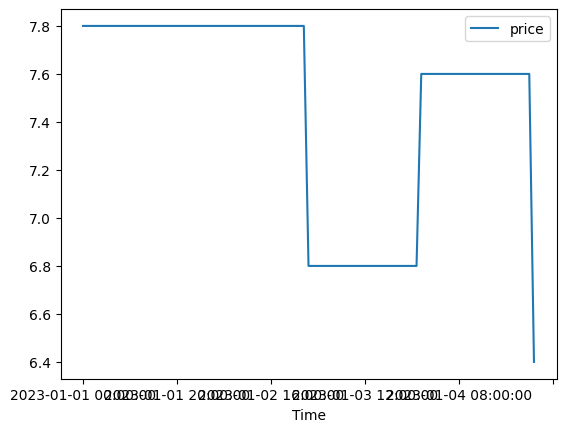

In [29]:
grid.loc[:"2023-01-05 00:00:00"].plot()

In [17]:


df =grid
# Assuming your DataFrame is named df
# Convert 'Time' to datetime and set it as the index
df['Time'] = pd.to_datetime(df['Time'], format='%d-%m-%Y %H:%M:%S')
df.set_index('Time', inplace=True)

# Resample per 60 minutes, forward filling the missing values
df_resampled = df.resample('60T').ffill()

# Check the resampled DataFrame
print(df_resampled)


                     price
Time                      
2023-01-01 00:00:00    7.8
2023-01-01 01:00:00    7.8
2023-01-01 02:00:00    7.8
2023-01-01 03:00:00    7.8
2023-01-01 04:00:00    7.8
...                    ...
2023-12-31 20:00:00    4.3
2023-12-31 21:00:00    4.3
2023-12-31 22:00:00    4.3
2023-12-31 23:00:00    4.3
2024-01-01 00:00:00    4.3

[8761 rows x 1 columns]


In [18]:
df_resampled

,price
Time,
2023-01-01 00:00:00,7.8
2023-01-01 01:00:00,7.8
2023-01-01 02:00:00,7.8
2023-01-01 03:00:00,7.8
2023-01-01 04:00:00,7.8
...,...
2023-12-31 20:00:00,4.3
2023-12-31 21:00:00,4.3
2023-12-31 22:00:00,4.3


In [116]:
im = grid[["Time","Agile Outgoing Unit Price (p)" ]]

In [117]:
im

,Time,Agile Outgoing Unit Price (p)
0,01-01-2023 00:00:00,3.0
1,01-01-2023 00:30:00,7.1
2,01-01-2023 01:00:00,7.7
3,01-01-2023 01:30:00,1.6
4,01-01-2023 02:00:00,4.0
...,...,...
17516,31-12-2023 22:00:00,7.1
17517,31-12-2023 22:30:00,5.5
17518,31-12-2023 23:00:00,5.2
17519,31-12-2023 23:30:00,3.5


In [21]:
df_resampled.to_csv("gas_tracker.csv", index=True)

In [105]:
grid

,Time,Flux Export Unit Price (p)
1,01-01-2023 00:00:00,NaN
2,01-01-2023 00:30:00,NaN
3,01-01-2023 01:00:00,NaN
4,01-01-2023 01:30:00,NaN
5,01-01-2023 02:00:00,NaN
...,...,...
17517,31-12-2023 22:00:00,16.9
17518,31-12-2023 22:30:00,16.9
17519,31-12-2023 23:00:00,16.9
17520,31-12-2023 23:30:00,16.9


In [106]:
import pandas as pd
import numpy as np

# Assuming your DataFrame is named df
# Convert the 'Time' column to datetime
df = grid
df['Time'] = pd.to_datetime(df['Time'], format='%d-%m-%Y %H:%M:%S')

# Define conditions based on the time of day
conditions = [
    (df['Time'].dt.hour >= 5) & (df['Time'].dt.hour < 16),  # 05:00 to 16:00
    (df['Time'].dt.hour >= 16) & (df['Time'].dt.hour < 19), # 16:00 to 19:00
    (df['Time'].dt.hour >= 19) | (df['Time'].dt.hour < 2),  # 19:00 to 02:00 (next day)
    (df['Time'].dt.hour >= 2) & (df['Time'].dt.hour < 5)    # 02:00 to 05:00
]

# Define corresponding values for each condition
values = [24.1, 38.1, 24.1, 10.0]

# Apply the conditions and fill the NaN values
df['Flux Export Unit Price (p)'] = np.where(df['Flux Export Unit Price (p)'].isna(),
                                            np.select(conditions, values, default=np.nan),
                                            df['Flux Export Unit Price (p)'])

# Check the updated DataFrame



In [107]:
df

,Time,Flux Export Unit Price (p)
1,2023-01-01 00:00:00,24.1
2,2023-01-01 00:30:00,24.1
3,2023-01-01 01:00:00,24.1
4,2023-01-01 01:30:00,24.1
5,2023-01-01 02:00:00,10.0
...,...,...
17517,2023-12-31 22:00:00,16.9
17518,2023-12-31 22:30:00,16.9
17519,2023-12-31 23:00:00,16.9
17520,2023-12-31 23:30:00,16.9


In [108]:
# Ensure 'Flux Import Unit Price (p)' is numeric, coerce invalid values to NaN
df['Flux Export Unit Price (p)'] = pd.to_numeric(df['Flux Export Unit Price (p)'], errors='coerce')


<Axes: >

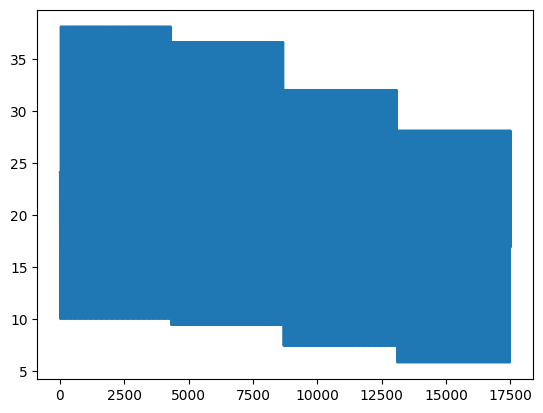

In [109]:
df['Flux Export Unit Price (p)'].plot()

In [110]:
grid.to_csv("flux_export.csv", index=False)

In [84]:
grid

,Time,Flux Import Unit Price (p)
1,01-01-2023 00:00:00,NaN
2,01-01-2023 00:30:00,NaN
3,01-01-2023 01:00:00,NaN
4,01-01-2023 01:30:00,NaN
5,01-01-2023 02:00:00,NaN
...,...,...
17517,31-12-2023 22:00:00,27.9
17518,31-12-2023 22:30:00,27.9
17519,31-12-2023 23:00:00,27.9
17520,31-12-2023 23:30:00,27.9


In [57]:
gas_import = pd.read_csv("/workspaces/CUBES/cubes/data/gas/csv_gastracker_A_Eastern_England_2023.csv", parse_dates=["timestamp"])

In [58]:
gas_import

,timestamp,price
0,2023-01-01 00:00:00+00:00,7.770
1,2023-01-01 00:10:00+00:00,7.770
2,2023-01-01 00:20:00+00:00,7.770
3,2023-01-01 00:30:00+00:00,7.770
4,2023-01-01 00:40:00+00:00,7.770
...,...,...
52412,2023-12-30 23:20:00+00:00,4.305
52413,2023-12-30 23:30:00+00:00,4.305
52414,2023-12-30 23:40:00+00:00,4.305
52415,2023-12-30 23:50:00+00:00,4.305


In [61]:
gas_import = pd.read_csv("/workspaces/CUBES/cubes/data/grid/minute_grid_carbon_GB_10min_2023.csv")

In [62]:
gas_import

,,GRID CARBON INTENSITY (gCO2/kWh)
0,2023-01-01 00:00:00+00:00,72.000000
1,2023-01-01 00:01:00+00:00,72.000000
2,2023-01-01 00:02:00+00:00,72.000000
3,2023-01-01 00:03:00+00:00,72.000000
4,2023-01-01 00:04:00+00:00,72.000000
...,...,...
525586,2023-12-31 23:46:00+00:00,63.333333
525587,2023-12-31 23:47:00+00:00,63.333333
525588,2023-12-31 23:48:00+00:00,63.333333
525589,2023-12-31 23:49:00+00:00,63.333333


<Axes: >

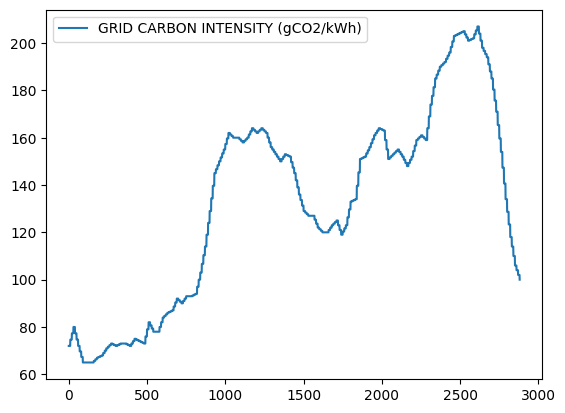

In [55]:
gas_import.iloc[:2881].plot()

In [52]:


# Convert your 'timestamp' column to datetime and remove the timezone info
gas_import['timestamp'] = pd.to_datetime(gas_import['timestamp']).dt.tz_localize(None)

# Create a DataFrame for all minutes in 2023 (without timezone)
all_minutes_2023 = pd.date_range(start="2023-01-01 00:00:00", end="2023-12-31 23:59:00", freq='T')

# Find missing timestamps by comparing
missing_timestamps = pd.Series(all_minutes_2023).loc[~pd.Series(all_minutes_2023).isin(gas_import['timestamp'])]

# Print the missing timestamps
print(missing_timestamps)


524161   2023-12-31 00:01:00
524162   2023-12-31 00:02:00
524163   2023-12-31 00:03:00
524164   2023-12-31 00:04:00
524165   2023-12-31 00:05:00
                 ...        
525595   2023-12-31 23:55:00
525596   2023-12-31 23:56:00
525597   2023-12-31 23:57:00
525598   2023-12-31 23:58:00
525599   2023-12-31 23:59:00
Length: 1439, dtype: datetime64[ns]


In [51]:
missing_timestamps

0        2023-01-01 00:00:00
1        2023-01-01 00:01:00
2        2023-01-01 00:02:00
3        2023-01-01 00:03:00
4        2023-01-01 00:04:00
                 ...        
525595   2023-12-31 23:55:00
525596   2023-12-31 23:56:00
525597   2023-12-31 23:57:00
525598   2023-12-31 23:58:00
525599   2023-12-31 23:59:00
Length: 525600, dtype: datetime64[ns]

In [35]:
elect_import = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_import/flux_import_tariff.csv", parse_dates=["Time"])
gas_import = pd.read_csv("/workspaces/CUBES/cubes/data/gas/minute_csv_gastracker_A_Eastern_England_2023.csv", parse_dates=["timestamp"])
agile = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_import/minute_csv_agile_A_Eastern_England_2023.csv", parse_dates=["timestamp"])
agile_export = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_export/minute_csv_agileoutgoing_A_Eastern_England_2023.csv", parse_dates=["timestamp"])

In [40]:
elect_export = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_export/flux_export_tariff.csv", parse_dates=["Time"])

In [42]:
elect_export

,Time,Flux Export Unit Price (p)
0,2023-01-01 00:00:00,24.1
1,2023-01-01 00:01:00,24.1
2,2023-01-01 00:02:00,24.1
3,2023-01-01 00:03:00,24.1
4,2023-01-01 00:04:00,24.1
...,...,...
525596,2023-12-31 23:56:00,16.9
525597,2023-12-31 23:57:00,16.9
525598,2023-12-31 23:58:00,16.9
525599,2023-12-31 23:59:00,16.9


In [ ]:
elect_import = elect_import.set_index(["Time"])
gas_import = gas_import.set_index(["timestamp"])
agile = agile.set_index(["timestamp"])
agile_export = agile_export.set_index(["timestamp"])

KeyError: "None of ['Time'] are in the columns"

In [43]:
elect_export = elect_export.set_index(["Time"])

In [30]:
len(elect_import.loc[:"2023-01-05 00:00:00"])

5761

In [31]:
len(gas_import.loc[:"2023-01-05 00:00:00"])

5761

In [32]:
len(agile.loc[:"2023-01-05 00:00:00"])

5761

In [39]:
len(agile_export.loc[:"2023-01-03 00:00:00"])

2881

<Axes: xlabel='Time'>

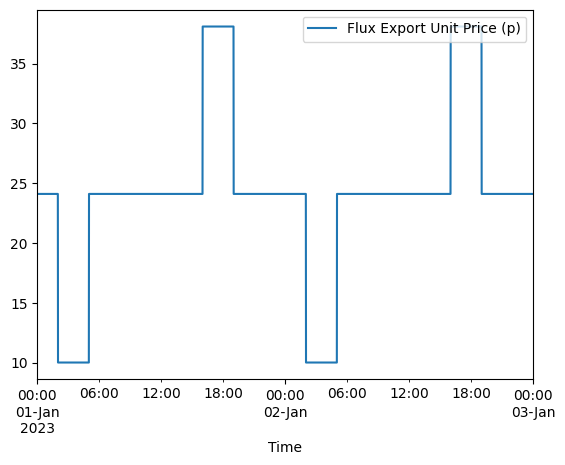

In [44]:
elect_export.loc[:"2023-01-03 00:00:00"].plot()


<Axes: xlabel='timestamp'>

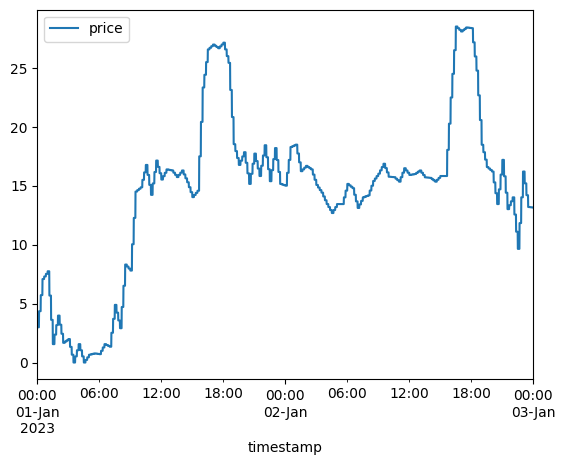

In [38]:
agile_export.loc[:"2023-01-03 00:00:00"].plot()


<Axes: xlabel='timestamp'>

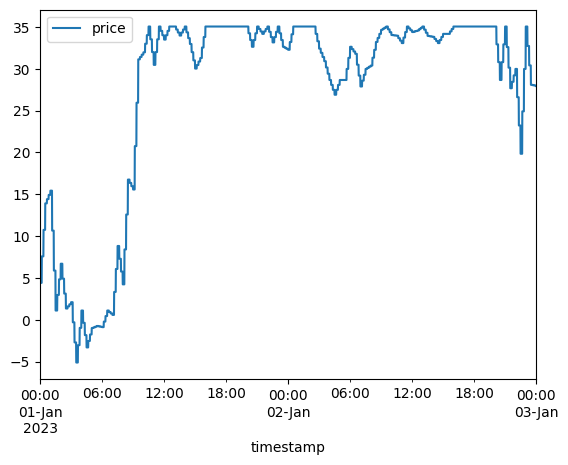

In [34]:
agile.loc[:"2023-01-03 00:00:00"].plot()


<Axes: xlabel='timestamp'>

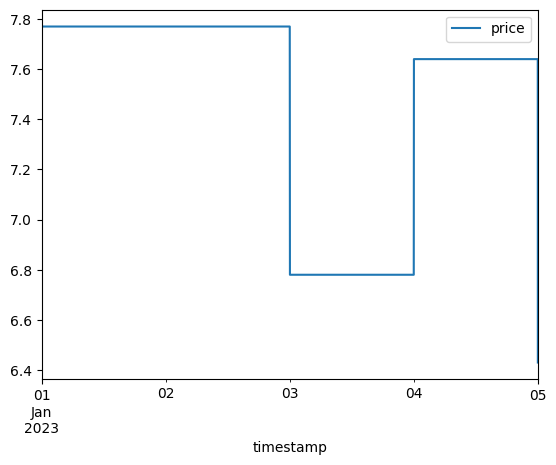

In [46]:
gas_import.loc[:"2023-01-05 00:00:00"].plot()


<Axes: xlabel='Time'>

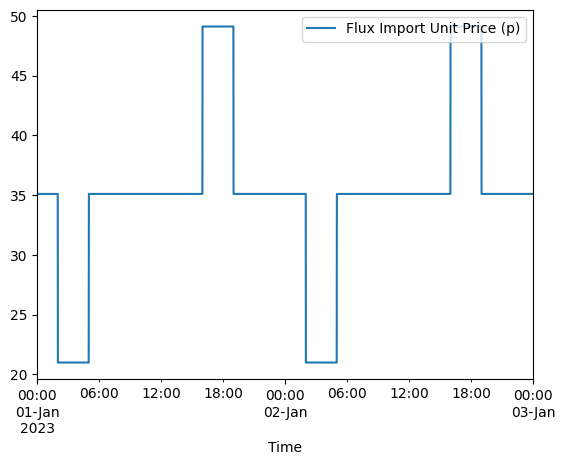

In [47]:
elect_import.loc[:"2023-01-03 00:00:00"].plot()

<Axes: xlabel='Time'>

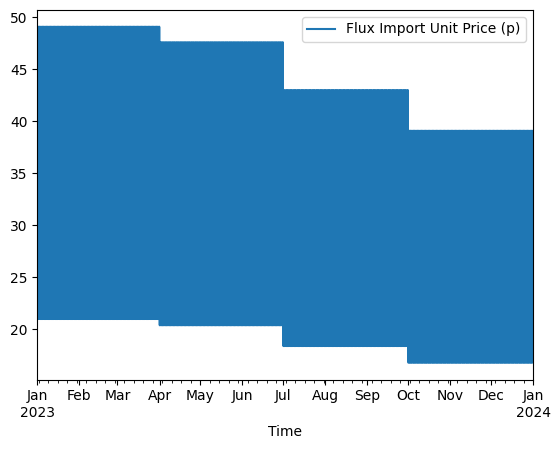

In [5]:
elect_import.plot()

In [12]:
import pandas as pd
import json

# Load the JSON data
json_file_path = "/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_21.0_t_setback_16.5_tags_longer_heating_check_v3/temp.json"
with open(json_file_path, "r") as f:
    temp_data = json.load(f)

# Helper function to create a DataFrame from percentage time and total counts
def create_metrics_df(data, counts):
    zones = data.keys()
    df = pd.DataFrame({
        "zone": zones,
        "Temperature": [data[zone]["Temperature"] for zone in zones],
        "Percentage_Time": [data[zone]["Percentage_Time"] for zone in zones],
        "Total_Count": [counts[zone] for zone in zones]
    })
    return df

# Extract data for in-hours air temp
in_hours_air_temp = temp_data["in_hours"]["air_temp"]["percentage_time"]
in_hours_air_count = temp_data["in_hours"]["air_temp"]["total_count"]

# Extract data for in-hours operative temp
in_hours_opr_temp = temp_data["in_hours"]["operative_temp"]["percentage_time"]
in_hours_opr_count = temp_data["in_hours"]["operative_temp"]["total_count"]

# Extract data for out-of-hours air temp
out_of_hours_air_temp = temp_data["out_of_hours"]["air_temp"]["percentage_time"]
out_of_hours_air_count = temp_data["out_of_hours"]["air_temp"]["total_count"]

# Extract data for out-of-hours operative temp
out_of_hours_opr_temp = temp_data["out_of_hours"]["operative_temp"]["percentage_time"]
out_of_hours_opr_count = temp_data["out_of_hours"]["operative_temp"]["total_count"]

# Create DataFrames for each category
df_in_hours_air = create_metrics_df(in_hours_air_temp, in_hours_air_count)
df_in_hours_opr = create_metrics_df(in_hours_opr_temp, in_hours_opr_count)
df_out_of_hours_air = create_metrics_df(out_of_hours_air_temp, out_of_hours_air_count)
df_out_of_hours_opr = create_metrics_df(out_of_hours_opr_temp, out_of_hours_opr_count)



In [16]:
df_out_of_hours_opr

,zone,Temperature,Percentage_Time,Total_Count
0,bedroom_1,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",61
1,front_room,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
2,hall_downstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
3,kitchen,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10
4,hall_upstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
5,bathroom,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",70
6,bedroom_2,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",90
7,bedroom_3,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",60


In [15]:
df_out_of_hours_air

,zone,Temperature,Percentage_Time,Total_Count
0,bedroom_1,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",61
1,front_room,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
2,hall_downstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
3,kitchen,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10
4,hall_upstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20
5,bathroom,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",70
6,bedroom_2,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",90
7,bedroom_3,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",60


In [5]:
json_file_path = "/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_21.0_t_setback_16.5_tags_longer_heating_check_v3/temp.json"

with open(json_file_path, "r") as f: temp_data = json.load(f)

in_hours_air_temp = temp_data["in_hours"]["air_temp"]["percentage_time"]

df = pd.DataFrame.from_dict(in_hours_air_temp, orient='index')

In [10]:
df

,Temperature,Percentage_Time
bedroom_2,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
bedroom_1,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
hall_downstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
kitchen,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
hall_upstairs,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
front_room,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
bathroom,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
bedroom_3,"[14.0, 14.1, 14.2, 14.299999999999999, 14.3999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [9]:
df.loc["bedroom_2", "Temperature"].plot()

AttributeError: 'list' object has no attribute 'plot'